In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("/content/drive/MyDrive/PROJECT/healthcare_dataset.csv")


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [6]:
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])


df['Stay Duration'] = (
    df['Discharge Date'] - df['Date of Admission']
).dt.days

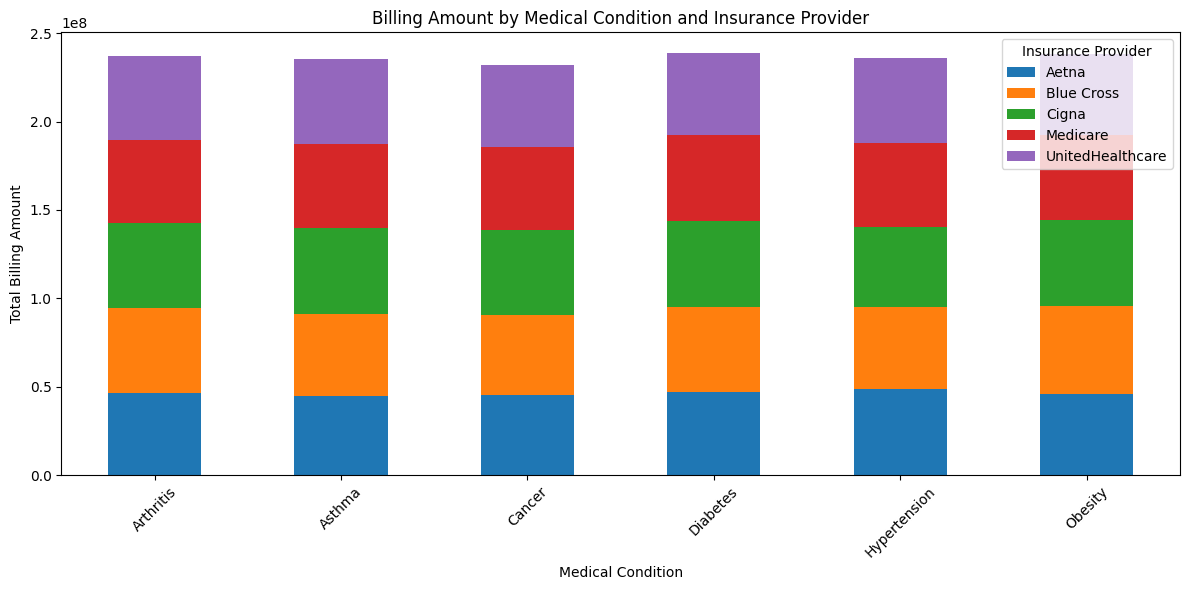

In [8]:
billing_data = pd.pivot_table(
    df,
    values='Billing Amount',
    index='Medical Condition',
    columns='Insurance Provider',
    aggfunc='sum'
)

billing_data.plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)
plt.title('Billing Amount by Medical Condition and Insurance Provider')
plt.xlabel('Medical Condition')
plt.ylabel('Total Billing Amount')
plt.xticks(rotation=45)
plt.legend(title='Insurance Provider')
plt.tight_layout()
plt.show()



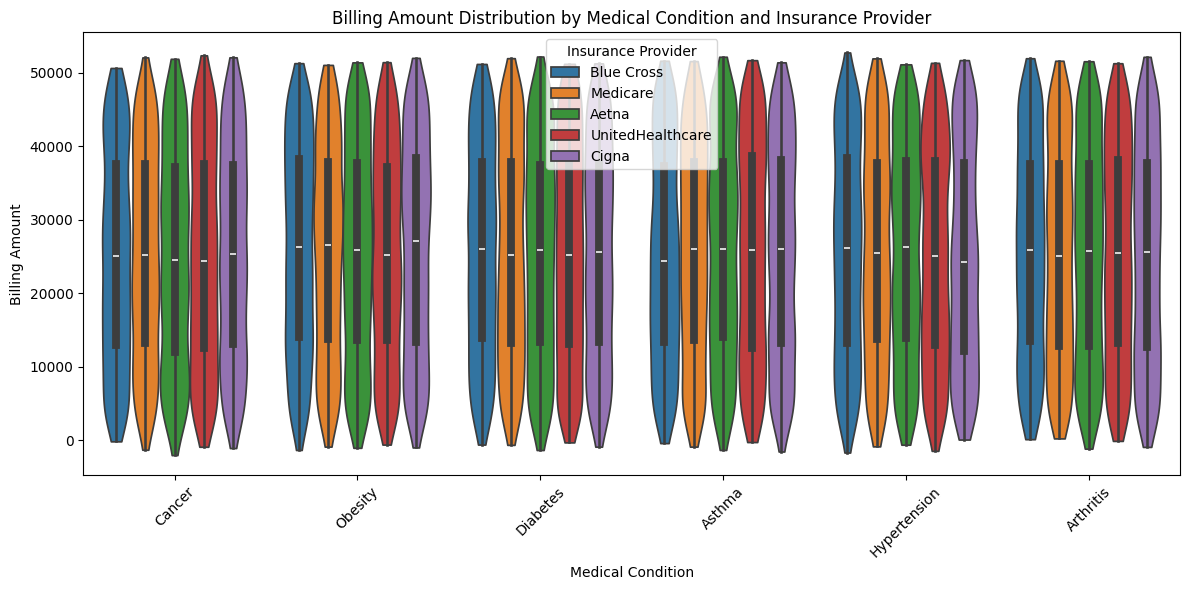

In [9]:
plt.figure(figsize=(12,6))

sns.violinplot(
    data=df,
    x='Medical Condition',
    y='Billing Amount',
    hue='Insurance Provider',
    cut=0
)

plt.title('Billing Amount Distribution by Medical Condition and Insurance Provider')
plt.xlabel('Medical Condition')
plt.ylabel('Billing Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
monthly_admissions = (
    df.set_index('Date of Admission')
      .resample('ME')
      .size()
)

print(monthly_admissions.head())

Date of Admission
2019-05-31     686
2019-06-30     907
2019-07-31     957
2019-08-31    1001
2019-09-30     936
Freq: ME, dtype: int64


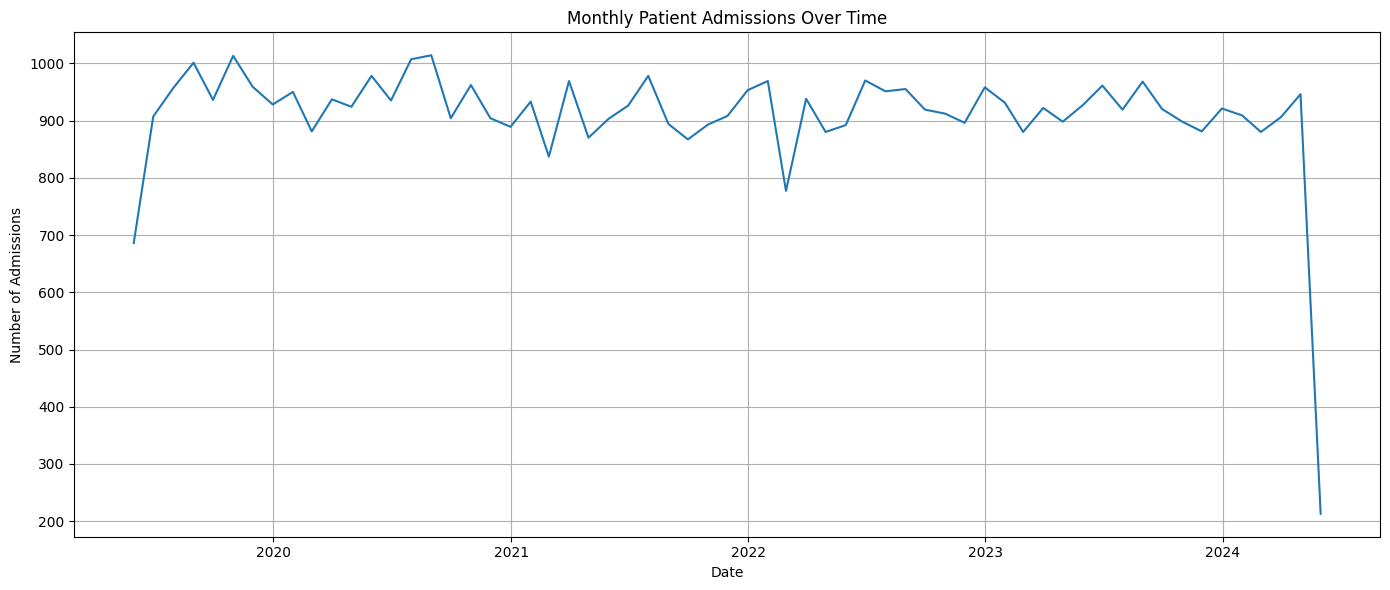

In [11]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_admissions.index,
    monthly_admissions.values
)

plt.title('Monthly Patient Admissions Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Admissions')
plt.grid(True)
plt.tight_layout()
plt.show()

In [12]:
corr_data = df[
    ['Age', 'Stay Duration', 'Billing Amount']
]
correlation = corr_data.corr()
print(correlation)

                     Age  Stay Duration  Billing Amount
Age             1.000000       0.008220       -0.003832
Stay Duration   0.008220       1.000000       -0.005602
Billing Amount -0.003832      -0.005602        1.000000


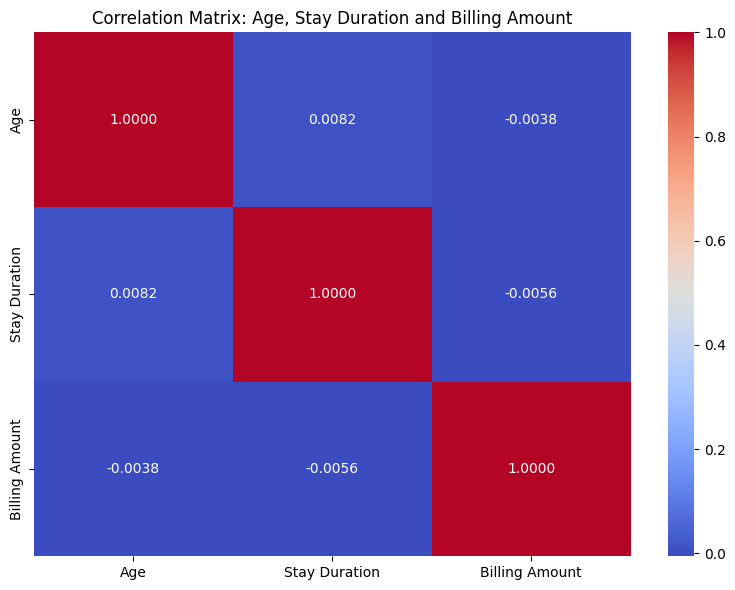

In [13]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation,
    annot=True,
    cmap='coolwarm',
    fmt='.4f'
)

plt.title('Correlation Matrix: Age, Stay Duration and Billing Amount')
plt.tight_layout()
plt.show()

In [14]:
condition_billing = (
    df.groupby('Medical Condition')['Billing Amount']
      .mean()
      .sort_values(ascending=False)
)

print(condition_billing)

Medical Condition
Obesity         25805.971259
Diabetes        25638.405577
Asthma          25635.249359
Arthritis       25497.327056
Hypertension    25497.095761
Cancer          25161.792707
Name: Billing Amount, dtype: float64


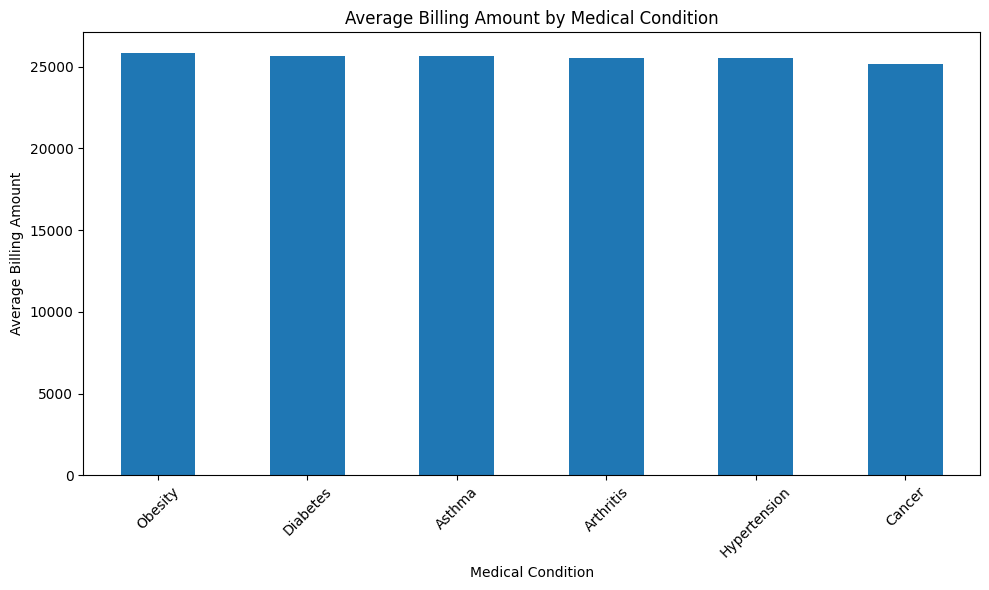

In [15]:
plt.figure(figsize=(10,6))

condition_billing.plot(kind='bar')

plt.title('Average Billing Amount by Medical Condition')
plt.xlabel('Medical Condition')
plt.ylabel('Average Billing Amount')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [16]:
provider_billing = (
    df.groupby('Insurance Provider')['Billing Amount']
      .mean()
      .sort_values(ascending=False)
)

print(provider_billing)

Insurance Provider
Medicare            25615.990508
Blue Cross          25613.011503
Aetna               25553.294506
Cigna               25525.766314
UnitedHealthcare    25389.172390
Name: Billing Amount, dtype: float64
